In [13]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1' 

%matplotlib widget
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import numpy as np
from temgym_core.components import Detector
from temgym_core.gaussian import (
    SigmoidAperture,
    run_to_end,
    circular_input_wave
)
from temgym_core.evaluate import (
    evaluate_gaussians_gpu_kernel_wrapper,
)

from temgym_core.utils import FresnelPropagator

jax.config.update("jax_enable_x64", True)

In [14]:
W = 10e-6  # Width of the simulation cell in nm

Nx = Ny = 256
center_idx = Nx // 2
dx = W/Nx
dy = W/Ny
grid = Detector(z=1e-1, pixel_size=(dx, dy), shape=(Nx, Ny))
coords = grid.coords
X, Y = coords[:,0].reshape(grid.shape), coords[:,1].reshape(grid.shape)
x, y = X[0,:], Y[:,0]
extent = (x[0], x[-1], y[0], y[-1])

voltage = 100e3  # in volts
components = (grid,)

In [15]:
num_rays = 2**18
rays_in = circular_input_wave(
    voltage=voltage,
    aperture_radius=W/4,
    waist=2e-8,
)

rays_in = rays_in.to_vector()

# Create JIT-ed single-ray and VMAP-ed batched versions without overwriting the original
run_to_end_jit = jax.jit(run_to_end)
run_to_end_vmapped = jax.jit(
    jax.vmap(run_to_end_jit, in_axes=(0, None)),
    static_argnums=(1,),
)


In [16]:
E_in = evaluate_gaussians_gpu_kernel_wrapper(rays_in, grid).block_until_ready()

In [17]:
rays_out = run_to_end_vmapped(rays_in, components)
E_prop = evaluate_gaussians_gpu_kernel_wrapper(rays_out, grid)

In [18]:
fresnel_diffraction_pattern = FresnelPropagator(E_in, W, wavelength=rays_in[0].wavelength, z=grid.z)

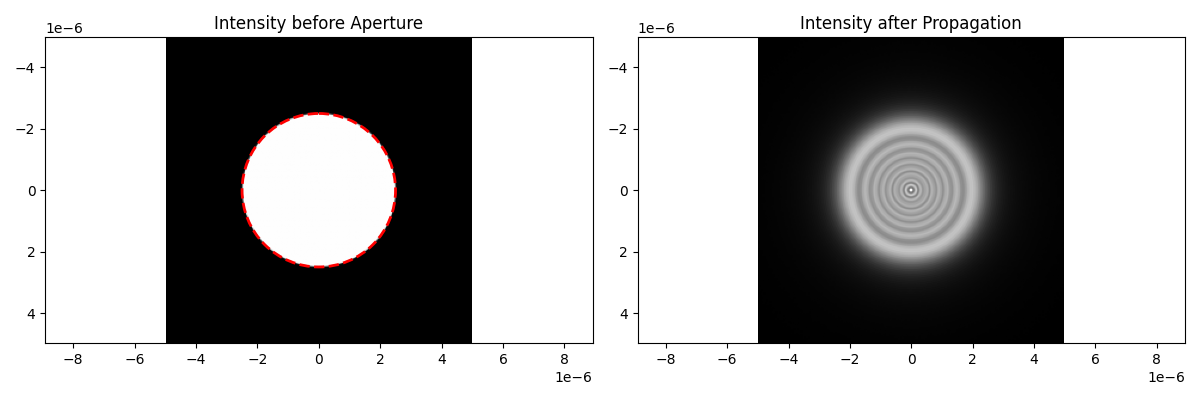

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Intensity before Aperture
axes[0].set_title('Intensity before Aperture')
axes[0].axis('equal')
circle = plt.Circle((0, 0), W / 4, color='red', fill=False, linestyle='--', linewidth=2)
axes[0].add_artist(circle)
axes[0].imshow(np.abs(E_in), cmap='gray', extent=extent)

# Intensity after Propagation
axes[1].set_title('Intensity after Propagation')
axes[1].axis('equal')
axes[1].imshow(np.abs(E_prop), cmap='gray', extent=extent)

plt.tight_layout()


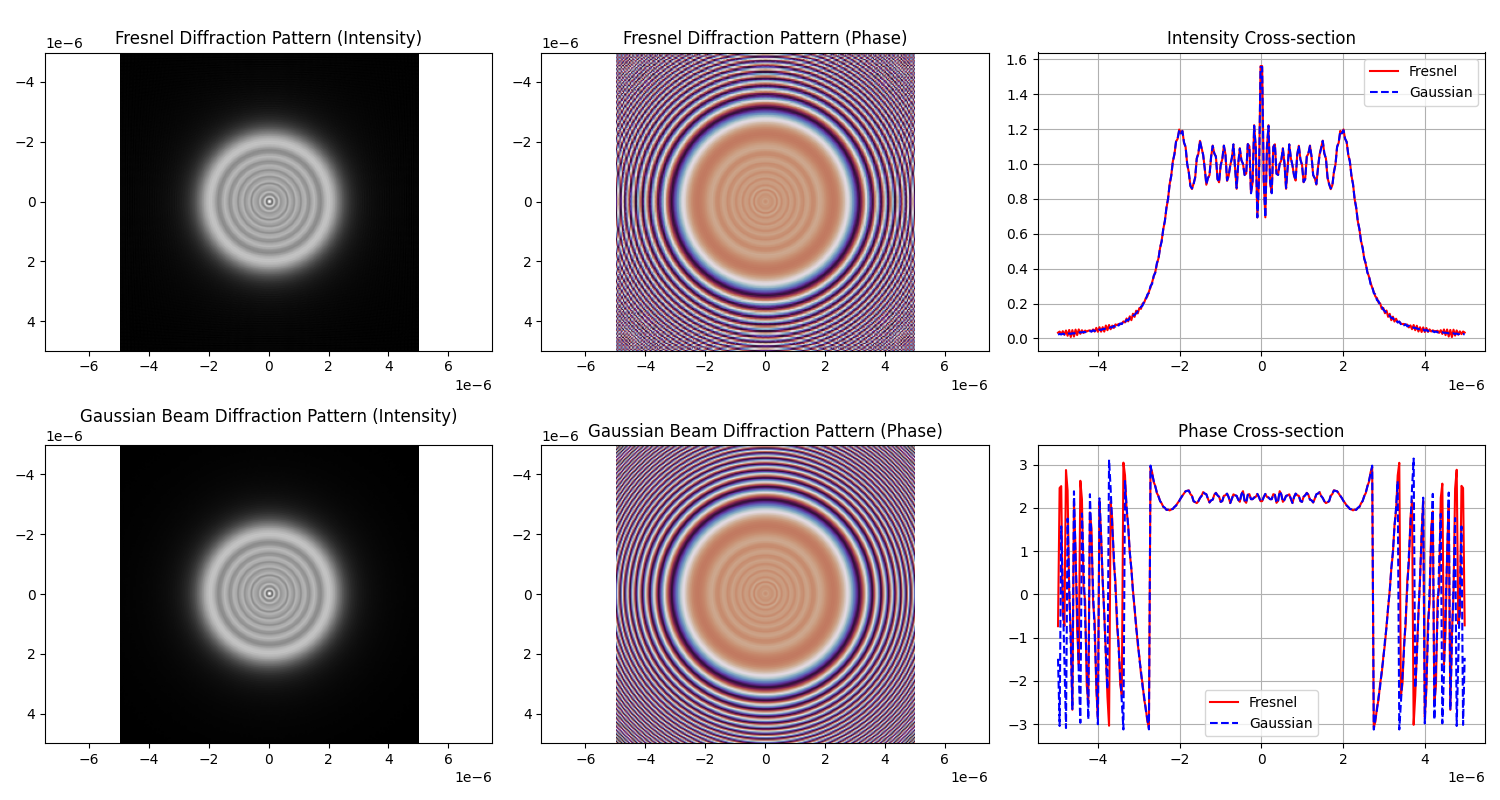

In [20]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

# Fresnel Diffraction Pattern - Intensity
axs[0, 0].imshow(np.abs(fresnel_diffraction_pattern), cmap='gray', extent=extent)
axs[0, 0].set_title('Fresnel Diffraction Pattern (Intensity)')
axs[0, 0].axis('equal')

# Fresnel Diffraction Pattern - Phase
axs[0, 1].imshow(np.angle(fresnel_diffraction_pattern), cmap='twilight', extent=extent)
axs[0, 1].set_title('Fresnel Diffraction Pattern (Phase)')
axs[0, 1].axis('equal')

# Gaussian Beam Diffraction Pattern - Intensity
axs[1, 0].imshow(np.abs(E_prop), cmap='gray', extent=extent)
axs[1, 0].set_title('Gaussian Beam Diffraction Pattern (Intensity)')
axs[1, 0].axis('equal')

# Gaussian Beam Diffraction Pattern - Phase
axs[1, 1].imshow(np.angle(E_prop), cmap='twilight', extent=extent)
axs[1, 1].set_title('Gaussian Beam Diffraction Pattern (Phase)')
axs[1, 1].axis('equal')

# Cross section - Intensity
axs[0, 2].plot(x, np.abs(fresnel_diffraction_pattern[center_idx, :]), color='red', label='Fresnel')
axs[0, 2].plot(x, np.abs(E_prop[center_idx, :]), color='blue', linestyle='--', label='Gaussian')
axs[0, 2].set_title('Intensity Cross-section')
axs[0, 2].legend()
axs[0, 2].grid(True)

# Cross section - Phase
axs[1, 2].plot(x, np.angle(fresnel_diffraction_pattern[center_idx, :]), color='red', label='Fresnel')
axs[1, 2].plot(x, np.angle(E_prop[center_idx, :]), color='blue', linestyle='--', label='Gaussian')
axs[1, 2].set_title('Phase Cross-section')
axs[1, 2].legend()
axs[1, 2].grid(True)

plt.tight_layout()